In [ ]:
!python --version

In [ ]:
!pip install "protobuf<=3.20.3" --force-reinstall

In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

In [ ]:
# Check GPU availability
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
if len(tf.config.list_physical_devices('GPU')) > 0:
    print("Training on GPU ✅")
else:
    print("Training on CPU ❌ (Go to Settings -> Accelerator -> GPU to enable)")

In [ ]:
dataset_root = None
for root, dirs, files in os.walk('/kaggle/input'):
    if 'apple' in dirs:
        dataset_root = root
        break

print(f"Dataset root found at: {dataset_root}")

In [ ]:
if dataset_root is None:
    print("Error: Could not find dataset root. Check if the dataset is added.")
else:
    print(f"Dataset root found at: {dataset_root}")

    all_classes = [d for d in os.listdir(dataset_root) if os.path.isdir(os.path.join(dataset_root, d))]
    print(f"All available classes: {all_classes}")

In [ ]:
    # Selecting 5 specific fruits
    target_fruits = ['apple', 'banana', 'orange', 'grape', 'pomegranate']
    
    # Filter for targets or just pick first 5
    selected_fruits = [f for f in all_classes if f in target_fruits]
    if len(selected_fruits) < 5:
        selected_fruits = all_classes[:5]

    print(f"Selected 5 Fruits for Training: {selected_fruits}")

In [23]:
filepaths = []
labels = []

# Ensure we have the dataset root
print(f"Dataset root found at: {dataset_root}")

for fruit in selected_fruits:
    fruit_path = os.path.join(dataset_root, fruit)
    
    # Recursively find all images inside the fruit folder
    for image_path in glob.glob(os.path.join(fruit_path, '**/*.*'), recursive=True):
        if image_path.lower().endswith(('.png', '.jpg', '.jpeg')):
            
            # 1. Get the quality (immediate parent folder, e.g., 'fresh' or 'rotten')
            quality = os.path.basename(os.path.dirname(image_path)).lower()
            
            # 2. Combine with fruit name
            # If the folder is "fresh", label becomes "fresh_apple"
            # If the folder is "rotten", label becomes "rotten_apple"
            
            # Safety check: if the path is weird and quality isn't fresh/rotten, fallback to fruit name
            if quality in ['fresh', 'rotten']:
                final_label = f"{quality}_{fruit}"
            else:
                # If the image is directly in the fruit folder, it might be mixed
                final_label = fruit 
            
            filepaths.append(image_path)
            labels.append(final_label)

df = pd.DataFrame({'filepath': filepaths, 'label': labels})

# Verify we now have roughly 10 classes
print(f"Total images: {len(df)}")
print(f"Classes Found ({len(df['label'].unique())}):")
print(df['label'].unique())

Dataset root found at: /kaggle/input/fruitquality1/Unified_Dataset
Total images: 15220
Classes Found (10):
['fresh_orange' 'rotten_orange' 'fresh_pomegranate' 'rotten_pomegranate'
 'fresh_apple' 'rotten_apple' 'fresh_grape' 'rotten_grape' 'fresh_banana'
 'rotten_banana']


In [24]:
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

# Image configuration
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Create Generators (Data Augmentation for training)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

# Load data from DataFrames
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filepath',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='filepath',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"Class Indices: {train_generator.class_indices}")

Found 12176 validated image filenames belonging to 10 classes.
Found 3044 validated image filenames belonging to 10 classes.
Class Indices: {'fresh_apple': 0, 'fresh_banana': 1, 'fresh_grape': 2, 'fresh_orange': 3, 'fresh_pomegranate': 4, 'rotten_apple': 5, 'rotten_banana': 6, 'rotten_grape': 7, 'rotten_orange': 8, 'rotten_pomegranate': 9}


In [26]:
from tensorflow.keras.layers import BatchNormalization, Concatenate, GlobalMaxPooling2D

# 1. Load Base Model
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# 2. Unfreeze last 40 layers (Increased from 30 for more fine-tuning power)
base_model.trainable = True
for layer in base_model.layers[:-40]:
    layer.trainable = False

# 3. Create Complex Head
# Get the raw features from MobileNet
base_out = base_model.output

# Dual Pooling: Concatenate both Average and Max pooling
# This gives the model two "perspectives" of the same image
avg_pool = GlobalAveragePooling2D()(base_out)
max_pool = GlobalMaxPooling2D()(base_out)
x = Concatenate()([avg_pool, max_pool]) 

# Dense Block 1 (High Capacity)
x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)  # Normalizes weights to speed up training
x = Dropout(0.4)(x)          # Stronger dropout to prevent overfitting

# Dense Block 2 (Refinement)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

# 4. Output Layer
num_classes = len(train_generator.class_indices)
predictions = Dense(num_classes, activation='softmax')(x)

# 5. Compile
model = Model(inputs=base_model.input, outputs=predictions)
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print(f"Complex Model successfully built for {num_classes} classes.")
model.summary()

Complex Model successfully built for 10 classes.


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 3,706,186 (14.14 MB)

 Trainable params: 3,128,202 (11.93 MB)

 Non-trainable params: 577,984 (2.20 MB)

In [27]:
EPOCHS = 10  
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
381/381 ━━━━━━━━━━━━━━━━━━━━ 288s 706ms/step - accuracy: 0.5999 - loss: 1.3031 - val_accuracy: 0.6922 - val_loss: 0.9841
Epoch 2/10
381/381 ━━━━━━━━━━━━━━━━━━━━ 254s 667ms/step - accuracy: 0.9273 - loss: 0.2268 - val_accuracy: 0.8035 - val_loss: 0.6922
Epoch 3/10
381/381 ━━━━━━━━━━━━━━━━━━━━ 253s 664ms/step - accuracy: 0.9554 - loss: 0.1375 - val_accuracy: 0.8463 - val_loss: 0.5522
Epoch 4/10
381/381 ━━━━━━━━━━━━━━━━━━━━ 253s 664ms/step - accuracy: 0.9675 - loss: 0.0979 - val_accuracy: 0.8476 - val_loss: 0.6038
Epoch 5/10
381/381 ━━━━━━━━━━━━━━━━━━━━ 250s 657ms/step - accuracy: 0.9778 - loss: 0.0651 - val_accuracy: 0.9678 - val_loss: 0.1064
Epoch 6/10
381/381 ━━━━━━━━━━━━━━━━━━━━ 249s 655ms/step - accuracy: 0.9840 - loss: 0.0498 - val_accuracy: 0.9750 - val_loss: 0.0750
Epoch 7/10
381/381 ━━━━━━━━━━━━━━━━━━━━ 254s 666ms/step - accuracy: 0.9890 - loss: 0.0389 - val_accuracy: 0.9855 - val_loss: 0.0419
Epoch 8/10
381/381 ━━━━━━━━━━━━━━━━━━━━ 253s 664ms/step - accuracy: 0.9886 -

In [28]:
model_save_path = 'fruit_classifier.h5'
model.save(model_save_path)
print(f"Model saved successfully: {model_save_path}")

Model saved successfully: fruit_classifier.h5


Running inference on 5 different fruits...


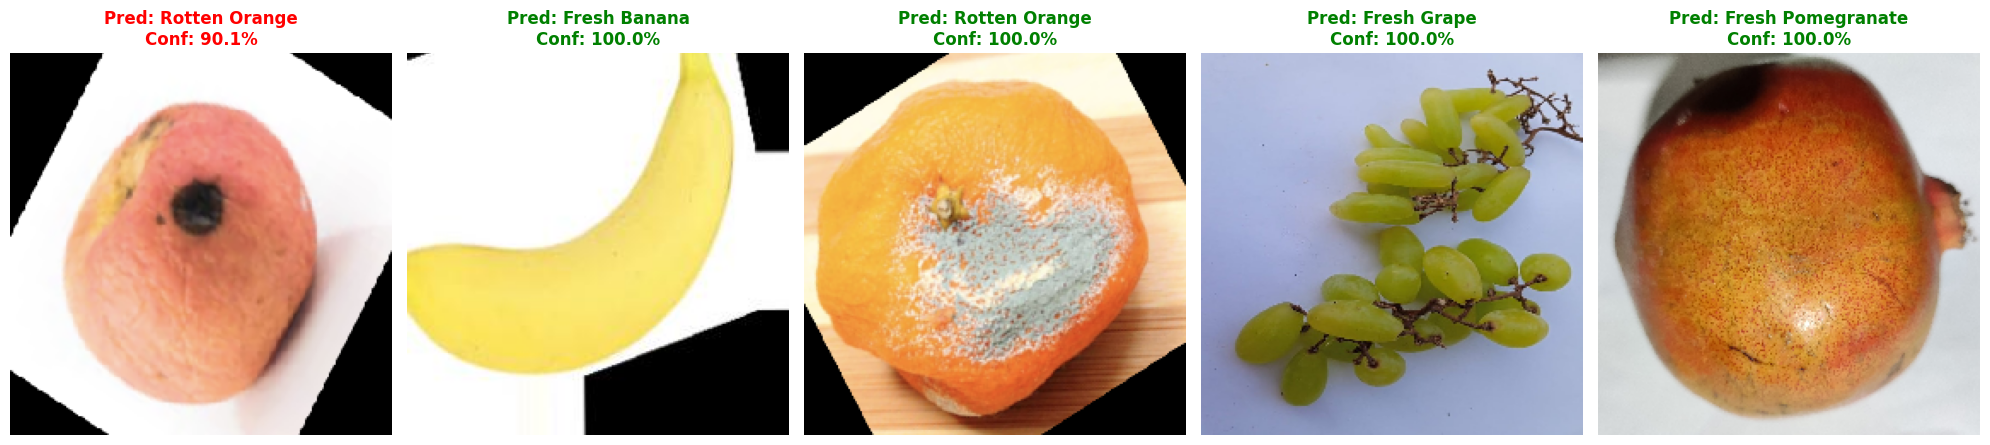

In [30]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing import image

def test_five_different_fruits(model, val_df, class_indices):
    # The 5 distinct fruits we want to test
    target_fruits = ['apple', 'banana', 'orange', 'grape', 'pomegranate']
    
    # Create a figure with 5 columns (one for each fruit)
    plt.figure(figsize=(20, 5))
    
    print("Running inference on 5 different fruits...")
    
    for i, fruit_name in enumerate(target_fruits):
        # 1. Filter the validation data to find rows matching this specific fruit
        # This looks for labels like 'fresh_apple' or 'rotten_apple'
        subset = val_df[val_df['label'].str.contains(fruit_name)]
        
        if subset.empty:
            print(f"Warning: No images found for {fruit_name}")
            continue
            
        # 2. Pick one random image for this fruit
        random_row = subset.sample(1).iloc[0]
        img_path = random_row['filepath']
        actual_raw_label = random_row['label']
        
        # 3. Preprocess
        img = image.load_img(img_path, target_size=(224, 224))
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array /= 255.0
        
        # 4. Predict
        prediction = model.predict(img_array, verbose=0) # verbose=0 keeps the log clean
        predicted_idx = np.argmax(prediction)
        confidence = np.max(prediction) * 100
        
        # 5. Decode Label
        idx_to_label = {v: k for k, v in class_indices.items()}
        predicted_raw_label = idx_to_label[predicted_idx]
        
        # Format text (e.g., "rotten_banana" -> "Rotten Banana")
        parts = predicted_raw_label.split('_')
        display_text = f"{parts[0].title()} {parts[1].title()}"
        
        # 6. Plot on the grid
        ax = plt.subplot(1, 5, i+1)
        plt.imshow(img)
        plt.axis('off')
        
        # Color Logic: Green if completely correct, Red if wrong
        # We check if the Predicted Label matches the Actual Label exactly
        status_color = 'green' if predicted_raw_label == actual_raw_label else 'red'
        
        plt.title(f"Pred: {display_text}\nConf: {confidence:.1f}%", 
                  color=status_color, fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.show()

# Run the function
test_five_different_fruits(model, val_df, train_generator.class_indices)

In [31]:
from IPython.display import FileLink

# This generates a blue clickable link to download your file
FileLink(r'fruit_classifier.h5')

/kaggle/working/fruit_classifier.h5

In [32]:
import os
import shutil
import random
from IPython.display import FileLink

# 1. Setup directories
source_dir = '/kaggle/input/fruitquality1/Unified_Dataset'  # Adjust if your path is different
output_dir = '/kaggle/working/sample_fruits'
zip_filename = 'sample_fruits_50.zip'

# Create the output directory if it doesn't exist
if os.path.exists(output_dir):
    shutil.rmtree(output_dir)
os.makedirs(output_dir)

# 2. Define your 10 classes
target_classes = [
    'fresh_apple', 'fresh_banana', 'fresh_grape', 'fresh_orange', 'fresh_pomegranate',
    'rotten_apple', 'rotten_banana', 'rotten_grape', 'rotten_orange', 'rotten_pomegranate'
]

print("Selecting 5 random images from each class...")

# 3. Loop through classes and copy images
total_copied = 0
for class_name in target_classes:
    # Handle the folder structure: The dataset might separate fruit/quality or combine them.
    # We will search recursively based on your previous successful dataframe logic.
    
    # Find all images for this specific class
    # We filter the 'df' you already created in previous steps
    subset = df[df['label'] == class_name]
    
    if subset.empty:
        print(f"Warning: No images found for {class_name}")
        continue
        
    # Pick 5 random images
    # If fewer than 5 exist, take all of them
    n_samples = min(5, len(subset))
    random_samples = subset.sample(n_samples)
    
    # Create class folder in output
    class_out_dir = os.path.join(output_dir, class_name)
    os.makedirs(class_out_dir, exist_ok=True)
    
    for _, row in random_samples.iterrows():
        src_path = row['filepath']
        # Create a unique filename to avoid conflicts
        filename = os.path.basename(src_path)
        dst_path = os.path.join(class_out_dir, filename)
        
        shutil.copy(src_path, dst_path)
        total_copied += 1

print(f"Successfully copied {total_copied} images to {output_dir}")

# 4. Zip the folder
shutil.make_archive('/kaggle/working/sample_fruits_50', 'zip', output_dir)
print(f"Zipped folder created: {zip_filename}")

# 5. Generate Download Link
FileLink(zip_filename)

Selecting 5 random images from each class...
Successfully copied 50 images to /kaggle/working/sample_fruits
Zipped folder created: sample_fruits_50.zip


/kaggle/working/sample_fruits_50.zip

Generating predictions (this may take a moment)...
96/96 ━━━━━━━━━━━━━━━━━━━━ 34s 317ms/step

CLASSIFICATION REPORT
                    precision    recall  f1-score   support

       fresh_apple       0.92      1.00      0.96       488
      fresh_banana       0.99      1.00      1.00       400
       fresh_grape       1.00      0.97      0.99        40
      fresh_orange       0.97      0.99      0.98       415
 fresh_pomegranate       0.93      0.95      0.94        40
      rotten_apple       1.00      0.81      0.89       585
     rotten_banana       1.00      1.00      1.00       559
      rotten_grape       0.98      1.00      0.99        40
     rotten_orange       0.91      1.00      0.95       437
rotten_pomegranate       0.66      0.97      0.79        40

          accuracy                           0.96      3044
         macro avg       0.94      0.97      0.95      3044
      weighted avg       0.96      0.96      0.96      3044


CONFUSION MATRIX


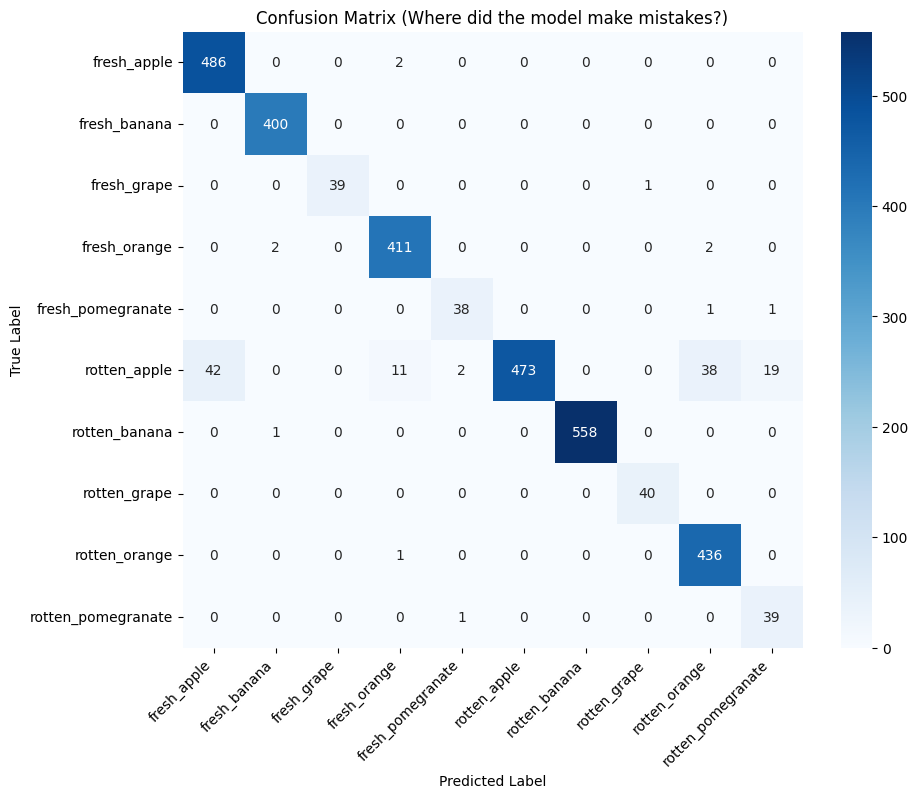

In [34]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

def evaluate_model_performance(model, generator):
    # 1. reset generator to start to ensure order matches
    generator.reset()
    
    print("Generating predictions (this may take a moment)...")
    # 2. Get predictions for all images
    # steps=len(generator) ensures we predict exactly all images once
    predictions = model.predict(generator, steps=len(generator), verbose=1)
    
    # 3. Convert probabilities to class indices (0, 1, 2...)
    predicted_classes = np.argmax(predictions, axis=1)
    
    # 4. Get true labels from the generator
    true_classes = generator.classes
    class_labels = list(generator.class_indices.keys())

    # --- METRICS REPORT ---
    print("\n" + "="*50)
    print("CLASSIFICATION REPORT")
    print("="*50)
    # This calculates Precision, Recall, F1-Score for each class
    report = classification_report(true_classes, predicted_classes, target_names=class_labels)
    print(report)

    # --- CONFUSION MATRIX ---
    print("\n" + "="*50)
    print("CONFUSION MATRIX")
    print("="*50)
    cm = confusion_matrix(true_classes, predicted_classes)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_labels, yticklabels=class_labels)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix (Where did the model make mistakes?)')
    plt.xticks(rotation=45, ha='right')
    plt.show()

# Run the evaluation on your Validation Generator
# (We use val_generator because it contains data the model didn't train on)
evaluate_model_performance(model, val_generator)